In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',50)
pd.set_option('display.max_colwidth',80)

plt.style.use('seaborn-v0_8-whitegrid')

In [17]:
df = pd.read_csv('../data/raw/developer-salary-survey.csv', low_memory=False)

print(f"Shape: {df.shape}")
print(f"Column count: {len(df.columns)}")
print(f"First 5 column names: {list(df.columns[:5])}")

Shape: (49191, 172)
Column count: 172
First 5 column names: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment']


In [18]:
list(df.columns[165:])

['AIAgentObsWrite',
 'AIAgentExternal',
 'AIAgentExtWrite',
 'AIHuman',
 'AIOpen',
 'ConvertedCompYearly',
 'JobSat']

In [19]:
# Checking whether we had target column
target_col ='ConvertedCompYearly'
print(f"Target Column Present: {target_col in df.columns}")

Target Column Present: True


In [20]:
# Check how many rows have salary values given
salary_available = df[target_col].notna().sum()

# Check missing rows
salary_missing = df[target_col].isna().sum()

print(f"Rows with Salary: {salary_available}")
print(f"Rows without salary: {salary_missing}")
print(f"Coverage: {salary_available/len(df)*100:.1f}%")

Rows with Salary: 23947
Rows without salary: 25244
Coverage: 48.7%


In [21]:
# Drop rows with missing values
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

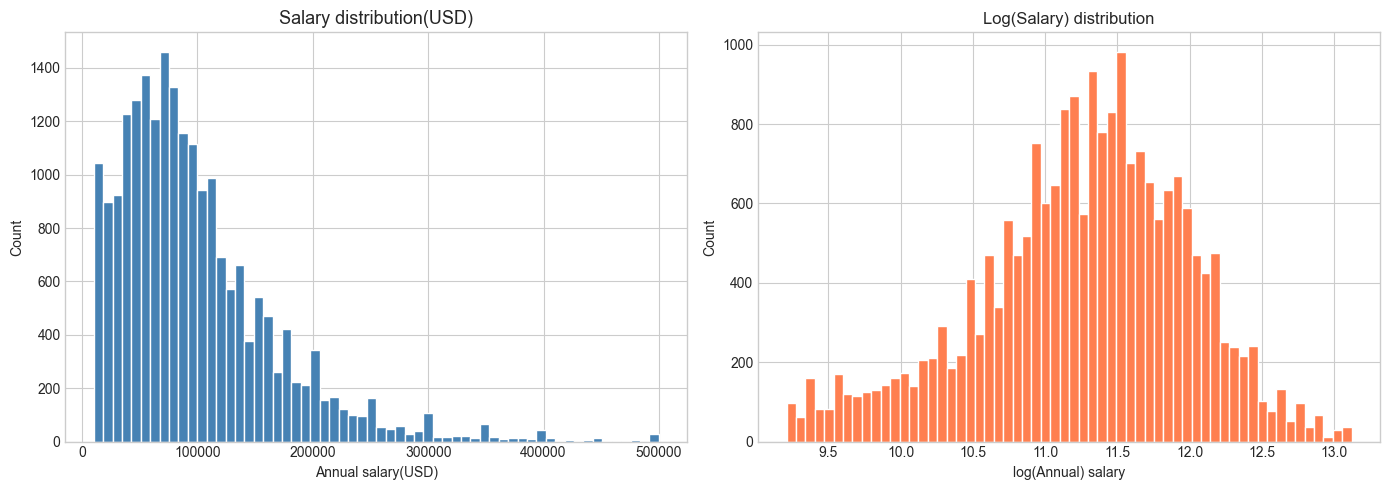

Median salary: $81,870
Mean salary: $98,572


In [22]:
salary_df = df[df[target_col].between(10000, 500000)]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# raw distribution
axes[0].hist(salary_df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)', fontsize=13)
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('Count')
 
#log-scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) distribution')
axes[1].set_xlabel('log(Annual) salary')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
plt.savefig('../data/salary_distribution.png', dpi=300)
plt.show()
 
print(f"Median salary: ${salary_df[target_col].median():,.0f}")
print(f'Mean salary: ${salary_df[target_col].mean():,.0f}')

Log transformation helps the graph look a bit normmal

In [23]:
df.shape

(49191, 172)

In [24]:
# Check null values
df.isnull().sum().sort_values(ascending=False)

AIAgentObsWrite      48927
SOTagsWant Entry     48761
SOTagsHaveEntry      48733
AIModelsWantEntry    48716
AIAgentOrchWrite     48713
                     ...  
EdLevel               1042
Employment             852
ResponseId               0
MainBranch               0
Age                      0
Length: 172, dtype: int64

In [25]:
df['PlatformHaveWorkedWith'].unique()

<ArrowStringArray>
[                                        'Amazon Web Services (AWS);Cloudflare;Firebase;Google Cloud;Gradle',
                 'Amazon Web Services (AWS);Datadog;Docker;Homebrew;Kubernetes;Maven (build tool);Terraform',
                                                                                 'Datadog;Firebase;npm;pnpm',
                                                                    'Amazon Web Services (AWS);Google Cloud',
                        'Amazon Web Services (AWS);APT;Docker;Make;Maven (build tool);MSBuild;npm;NuGet;Pip',
                                                    'Amazon Web Services (AWS);Google Cloud;Microsoft Azure',
                                                'Amazon Web Services (AWS);Docker;Homebrew;npm;pnpm;Webpack',
                                        'Amazon Web Services (AWS);APT;Docker;Google Cloud;Homebrew;npm;Pip',
                                           'Amazon Web Services (AWS);Datadog;Docker;Microsoft Azure;

In [27]:
df['DatabaseHaveWorkedWith'].unique()

<ArrowStringArray>
[                                                                                      'Cloud Firestore;PostgreSQL',
                                                                                                 'Dynamodb;MongoDB',
                                                                                         'MongoDB;MySQL;PostgreSQL',
                                                                                                                nan,
                                          'Elasticsearch;Microsoft SQL Server;MySQL;Oracle;PostgreSQL;Redis;SQLite',
                                                                                        'MongoDB;PostgreSQL;SQLite',
 'Cassandra;Databricks SQL;DuckDB;Dynamodb;MariaDB;Microsoft SQL Server;MySQL;PostgreSQL;Snowflake;Amazon Redshift',
                                                                         'H2;Microsoft SQL Server;PostgreSQL;Redis',
                                             

In [29]:
df["DevType"].unique()

<ArrowStringArray>
[                            'Developer, mobile',
                           'Developer, back-end',
                          'Developer, front-end',
                           'Engineering manager',
                         'Developer, full-stack',
              'Architect, software or solutions',
                                 'Data engineer',
                 'Financial analyst or engineer',
                           'Academic researcher',
   'Developer, embedded applications or devices',
         'Cybersecurity or InfoSec professional',
                   'Developer, game or graphics',
                                'AI/ML engineer',
          'Senior executive (C-suite, VP, etc.)',
 'Developer, desktop or enterprise applications',
                       'Other (please specify):',
              'Founder, technology or otherwise',
                                       'Retired',
             'Developer, AI apps or physical AI',
               'DevOps engineer

In [33]:
df['Age'].unique()

<ArrowStringArray>
[  '25-34 years old',   '35-44 years old',   '45-54 years old',
   '18-24 years old', '65 years or older',   '55-64 years old',
 'Prefer not to say']
Length: 7, dtype: str

In [34]:
df['RemoteWork'].unique()

<ArrowStringArray>
[                                                                      'Remote',
                          'Hybrid (some in-person, leans heavy to flexibility)',
                                                                            nan,
                                                                    'In-person',
                               'Hybrid (some remote, leans heavy to in-person)',
 'Your choice (very flexible, you can come in when you want or just as needed)']
Length: 6, dtype: str

In [35]:
df['Industry'].unique()

<ArrowStringArray>
[                                   'Fintech',
               'Retail and Consumer Services',
                       'Software Development',
                                  'Insurance',
                 'Banking/Financial Services',
                                          nan,
                                 'Government',
                                     'Energy',
                           'Higher Education',
               'Media & Advertising Services',
                              'Manufacturing',
 'Internet, Telecomm or Information Services',
       'Computer Systems Design and Services',
                                     'Other:',
            'Transportation, or Supply Chain',
                                 'Healthcare']
Length: 16, dtype: str

In [10]:
drop_list=[]
 
target= 'ConvertCompYearly'
 
for col in df.columns.to_list():
    if col== target:
        pass
    else:
        if df[col].isnull().sum() > len(df)/2:
            drop_list.append(col)
            df.drop(columns=[col], inplace= True)
            drop_list.append(col)
 
len(drop_list)

142

# Data cleaning

# Explore selected features
features =['country','YearsCodepro','Edlevel','employment','Language', Have worked with']

missing columns/rows and how to deal with them
data types hwo do the olumns look like
map heatmap to check for correlation and what are you going to about it

In [11]:
# Explore the selected features
features =['Country','YearsCode','Edlevel','Employment','LanguageHaveWorkedWith']

for col in features:
    if col in df.columns:
        missing_pct=df[col].isna().mean()*100
        unique_count=df[col].nunique() #nunique  - returns the number of unique items(int), .unique( returns the actual value ofunique items)

        print('column', col)
        print("Missing, ", missing_pct)
        print("Unique values count: ", unique_count)
        print(" First 5 rows: ")
        print(df[col].value_counts().head().to_string())
        print()

column Country
Missing,  27.96039926002724
Unique values count:  177
 First 5 rows: 
Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409

column YearsCode
Missing,  12.500254111524466
Unique values count:  78
 First 5 rows: 
YearsCode
10.0    3108
15.0    2540
20.0    2497
5.0     2267
8.0     2113

column Employment
Missing,  1.7320241507592853
Unique values count:  6
 First 5 rows: 
Employment
Employed                                                33750
Independent contractor, freelancer, or self-employed     6708
Student                                                  4428
Not employed                                             2227
Retired                                                   708

column LanguageHaveWorkedWith

In [12]:
# Data frame of the number of  people who earn between 10000 and 400,000
df_sal =df[df[target_col].between(10_000,400_000)].copy()

top_countries =df_sal['Country'].value_counts().head(15).index
top_countries

# Conclusion is that united states has the highest number of people  who earn between that range
country_data =df_sal[df_sal['Country'].isin(top_countries)]

plt.figure(figsize=(14,6))
order = country_data.groupby('Country')[target_col].median().sort_values(ascending=False).index

sns.boxplot(
    data=country_data,
    x='Country', y=target_col,
    order =order,
    palette ='coolwarm'
)
plt.xticks(rotation=45, ha='right')
plt.title('Salary by country (Top 15 respondents by count)')
plt.ylabel('Annual Salary(USD)')
plt.tight_layout()
plt.savefig('../data/salary_by_country.png',dpi=300)
plt.show()


KeyError: 'ConvertedCompYearly'

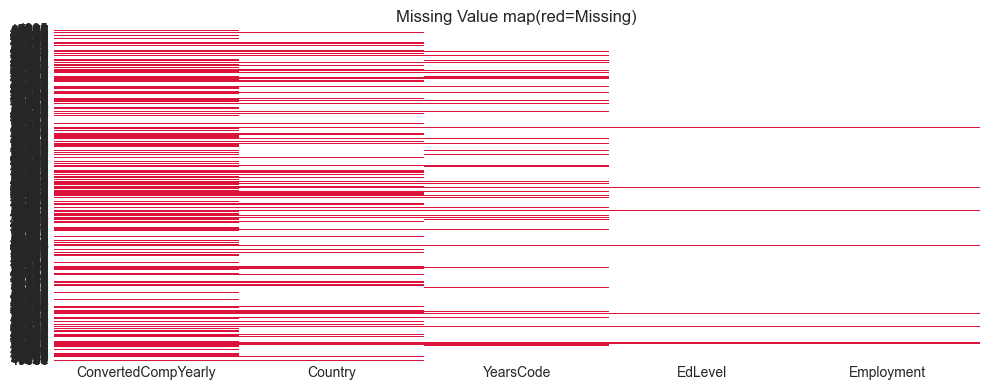

In [ ]:
selected_cols=[target_col,'Country','Edlevel','YearsCode','EdLevel','Employment']
available_cols=[c for c in selected_cols if c in df.columns]

missing_df =df[available_cols].isna()

plt.figure(figsize=(10,4))
sns.heatmap(missing_df.sample(min(1000,len(df)),random_state=42),
            cbar=False, yticklabels=True, xticklabels=True,
            cmap=['white','crimson'])
plt.title('Missing Value map(red=Missing)')
plt.tight_layout()
plt.show()

# 3. Feature selection and cleaning
Feature selection and cleaning: 
1. Feature decisions - which features do want to use and why. is cleaning needed? 
2. Create a preprocessing file, ie src/preprocessing.py, have several cleaning functions, then after cleaning the data, 
3. Pipeline and model training

Standardize features

In [ ]:
df['LanguageHaveWorkedWith'].unique()

<ArrowStringArray>
[                                                                     'Bash/Shell (all shells);Dart;SQL',
                                                                                                  'Java',
                                                                   'Dart;HTML/CSS;JavaScript;TypeScript',
                                                                                       'Java;Kotlin;SQL',
 'C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;PowerShell;Python;SQL;TypeScript;VBA;Visual Basic (.Net)',
                                                                                            'Java;Scala',
                                                                                 'JavaScript;TypeScript',
                                     'Bash/Shell (all shells);HTML/CSS;JavaScript;Python;SQL;TypeScript',
                                                                                     'Java;Python;Scala',
                           

In [ ]:
df['EdLevel'].unique()

<ArrowStringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                             'Some college/university study without earning a degree',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                            'Other (please specify):',
                                                          'Primary/elementary school',
                                                                                  nan]
Length: 9, dtype: str

In [ ]:
df['Employment'].unique()

<ArrowStringArray>
[                                            'Employed',
 'Independent contractor, freelancer, or self-employed',
                                              'Student',
                                              'Retired',
                                         'Not employed',
                                  'I prefer not to say',
                                                    nan]
Length: 7, dtype: str

In [ ]:
df['Country'].unique()

<ArrowStringArray>
[                 'Ukraine',              'Netherlands',
                    'India',                  'Georgia',
                'Australia',                   'Greece',
                  'Germany',               'Bangladesh',
                   'Brazil', 'United States of America',
 ...
                   'Gambia',                   'Malawi',
                    'Niger',                  'Lesotho',
               'San Marino',                 'Djibouti',
                  'Burundi',               'Cape Verde',
                    'Palau',                   'Guinea']
Length: 178, dtype: str

In [ ]:
df['YearsCode'].unique()

array([ 14.,  10.,  12.,   5.,  22.,  20.,  13.,  30.,  15.,   9.,   6.,
        nan,   3.,  40.,   8.,  45.,  35.,  11.,   7.,  47.,  41.,  36.,
        23.,  29.,  26.,  25.,  38.,  21.,  19.,  18.,  16.,   4.,  17.,
        42.,  27.,  24.,   2.,  28.,  37.,  32.,   1.,  39.,  53.,  33.,
        50.,  48.,  44.,  31.,  46.,  43.,  49.,  52.,  34.,  51.,  58.,
        57.,  54.,  63.,  60.,  55.,  65., 100.,  99.,  56.,  69.,  90.,
        61.,  67.,  75.,  64.,  98.,  68.,  89.,  62.,  78.,  70.,  76.,
        82.,  59.])

In [15]:
import sys
import os

sys.path.insert(0, os.path.dirname("../src/"))

from preprocessing import load_and_clean, get_feature_columns, TARGET

# This is going to load and clean the data
df= load_and_clean("../data/raw/developer-salary-survey.csv")
df.to_csv("../data/cleaned/processed-data.csv", index=False)

SyntaxError: expected ':' (preprocessing.py, line 88)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Splitting the data 

non_target =[c for c in df.columns if c != TARGET]
X =df[non_target]
y = df[TARGET]

    

X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2)
print(f"Train: {X_train.shape} Test:{X_test.shape}")



Train: (16962, 5) Test:(4241, 5)


In [ ]:
# Creating the pipelines
# Creating the pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder())

])
cat_cols, num_cols = get_feature_columns(df)

preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat', cat_pipeline,cat_cols)
    ])

In [ ]:
from xgboost import XGBRegressor

In [ ]:
# Full pipeline and train the model
F_pipe = Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBRegressor())
])

In [ ]:
# Prediction
X_train.info()

<class 'pandas.DataFrame'>
Index: 16962 entries, 4752 to 15682
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 16962 non-null  str    
 1   YearsCode               16913 non-null  float64
 2   EdLevel                 16962 non-null  str    
 3   Employment              16962 non-null  str    
 4   LanguageHaveWorkedWith  15857 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.3 MB


In [ ]:
F_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
y_pred=F_pipe.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

mse=mean_squared_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
print("The mean squared error is", mse )
print(" The r2 score is", r2score*100)


The mean squared error is 3039614412.364441
 The r2 score is 36.32291923594016


# Target encoding for country
pick 25 countries then we do taarget encoding
# Changes
1. Add more features -We've added 10 features from raw data but its yet to be processed
This helps deal with underfitting
2. Log transform our target column as it was rightly skewed-its now log_salary
3. Hyper parameter tuning-Tune Xgboost parameters,tune n_estimators,max_depth,learning_rate, Perform regularization 'reg_alpha'-it does L1 regularization, 'reg_lambda'-performs l2 regularization(weight shrinkage)
4. Target encoding -country/Devtype/industry
5. Ordinal encoding -edlevel,remotework,age
6. Interaction features- 
Python
    def add_intercation_features(df):
        df['yearsCode_sq'] = df['YearsCode'] ** 2
        df['WorkExp_sq'] = df['WorkExp'] ** 2
        df['Exp_ratio'] = df['WorkExp']/ (df['YearsCode'] + 1)
        df['Tech_breadth'] = (df['LanguageCount'] + df['DatabaseCount'] + df['PlatformCount']).fillna(0)
        return df

In [36]:
df['PlatformHaveWorkedWith'].unique()

<ArrowStringArray>
[                                        'Amazon Web Services (AWS);Cloudflare;Firebase;Google Cloud;Gradle',
                 'Amazon Web Services (AWS);Datadog;Docker;Homebrew;Kubernetes;Maven (build tool);Terraform',
                                                                                 'Datadog;Firebase;npm;pnpm',
                                                                    'Amazon Web Services (AWS);Google Cloud',
                        'Amazon Web Services (AWS);APT;Docker;Make;Maven (build tool);MSBuild;npm;NuGet;Pip',
                                                    'Amazon Web Services (AWS);Google Cloud;Microsoft Azure',
                                                'Amazon Web Services (AWS);Docker;Homebrew;npm;pnpm;Webpack',
                                        'Amazon Web Services (AWS);APT;Docker;Google Cloud;Homebrew;npm;Pip',
                                           'Amazon Web Services (AWS);Datadog;Docker;Microsoft Azure;

# lEARN SMOOTHING, early stopping
How to improve r2_score:
1. Stacking ensemble models